## The Halting Problem & Machine Learning Approximation

### Understanding the Halting Problem
The Halting Problem is a foundational dilemma in computer science, formulated and proved undecidable by Alan Turing in 1936. It asks a simple question: Given an arbitrary computer program and an input, can we create a general algorithm that decides whether the program will finish running (halt) or run forever (infinite loop)?

Turing proved that a perfect, universal program to solve this is **mathematically impossible**. If we try to create a deterministic function $H(P, I)$, it leads to a logical paradox (diagonalization argument) where the analyzer cannot correctly predict its own behavior.

### Mathematical Framework
Let $P$ represent a program and $I$ represent its input. The idealized halting function is defined as:
$$H(P, I) = \begin{cases} 1 & \text{if } P(I) \text{ terminates within finite steps} \\ 0 & \text{if } P(I) \text{ loops infinitely} \end{cases}$$

Since $H(P, I)$ cannot be computed deterministically for all possible programs, we use Machine Learning to build a **probabilistic static analyzer**. We look at structural and complexity metrics of code to approximate the likelihood of a program halting.

We define this as a **Binary Classification** task. For a given feature vector $x \in \mathbb{R}^d$ representing code metrics, the model estimates:
$$\hat{y} = P(Y = 1 \mid x)$$

Where:
* $Y = 1$: The program halts.
* $Y = 0$: The program encounters an infinite loop.

The model is optimized by minimizing the **Binary Cross-Entropy Loss**:
$$\mathcal{L}(y, \hat{y}) = -\frac{1}{N} \sum_{i=1}^{N} \left[ y_i \log(\hat{y}_i) + (1 - y_i) \log(1 - \hat{y}_i) \right]$$


In [2]:
# Import core data science and visualization libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Import machine learning components
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

# Configure runtime environment settings
import warnings
warnings.filterwarnings('ignore')

# Set aesthetic styling for data visualization
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

print("Environment successfully configured. Ready for data injection.")


Environment successfully configured. Ready for data injection.


In [3]:
# Synthetic Dataset Generation representing code structures
np.random.seed(42)
num_samples = 1500

# Generating static code features:
# - loop_count: Number of iteration loops in the source code
# - nested_depth: Maximum nesting level of loops and conditions
# - cyclomatic_complexity: Number of independent execution paths
# - has_break_condition: Binary indicator (1 = explicit exit condition present, 0 = absent)
# - recursion_depth: Maximum depth of recursive functions
# - lines_of_code: Total physical size of the program

loop_count = np.random.randint(0, 5, num_samples)
nested_depth = np.random.randint(0, 4, num_samples)
cyclomatic_complexity = loop_count * 2 + nested_depth + np.random.randint(1, 10, num_samples)
has_break_condition = np.random.choice([0, 1], size=num_samples, p=[0.3, 0.7])
recursion_depth = np.random.randint(0, 20, num_samples) * np.random.choice([0, 1], size=num_samples, p=[0.8, 0.2])
lines_of_code = cyclomatic_complexity * 5 + np.random.randint(5, 50, num_samples)

# Assemble into a clean DataFrame
df = pd.DataFrame({
    'loop_count': loop_count,
    'nested_depth': nested_depth,
    'cyclomatic_complexity': cyclomatic_complexity,
    'has_break_condition': has_break_condition,
    'recursion_depth': recursion_depth,
    'lines_of_code': lines_of_code
})

# Formulate underlying non-linear logic determining the execution state (with noise)
# High loops, deep nesting, and no break conditions increase risk of infinite execution
score = (df['loop_count'] * 1.8 + df['nested_depth'] * 2.2 + (df['recursion_depth'] > 12) * 2.5) - (df['has_break_condition'] * 4.5)
probability = 1 / (1 + np.exp(score)) # Logistic sigmoid distribution

# Assign classification labels: 1 for Halting, 0 for Infinite Loop
df['halts'] = (probability > 0.5).astype(int)

print(f"Data pipeline complete. Dataset shape: {df.shape}")
print("\nTarget class distribution:")
print(df['halts'].value_counts(normalize=True))


Data pipeline complete. Dataset shape: (1500, 7)

Target class distribution:
halts
0    0.802
1    0.198
Name: proportion, dtype: float64


## Exploratory Data Analysis (EDA)

Before training our machine learning models, we must visualize the dataset to understand how static code metrics correlate with the software's final execution state (Halting vs. Infinite Loop). This helps verify if our synthetic logic reflects real-world programming patterns (e.g., highly nested loops increasing the probability of non-termination).


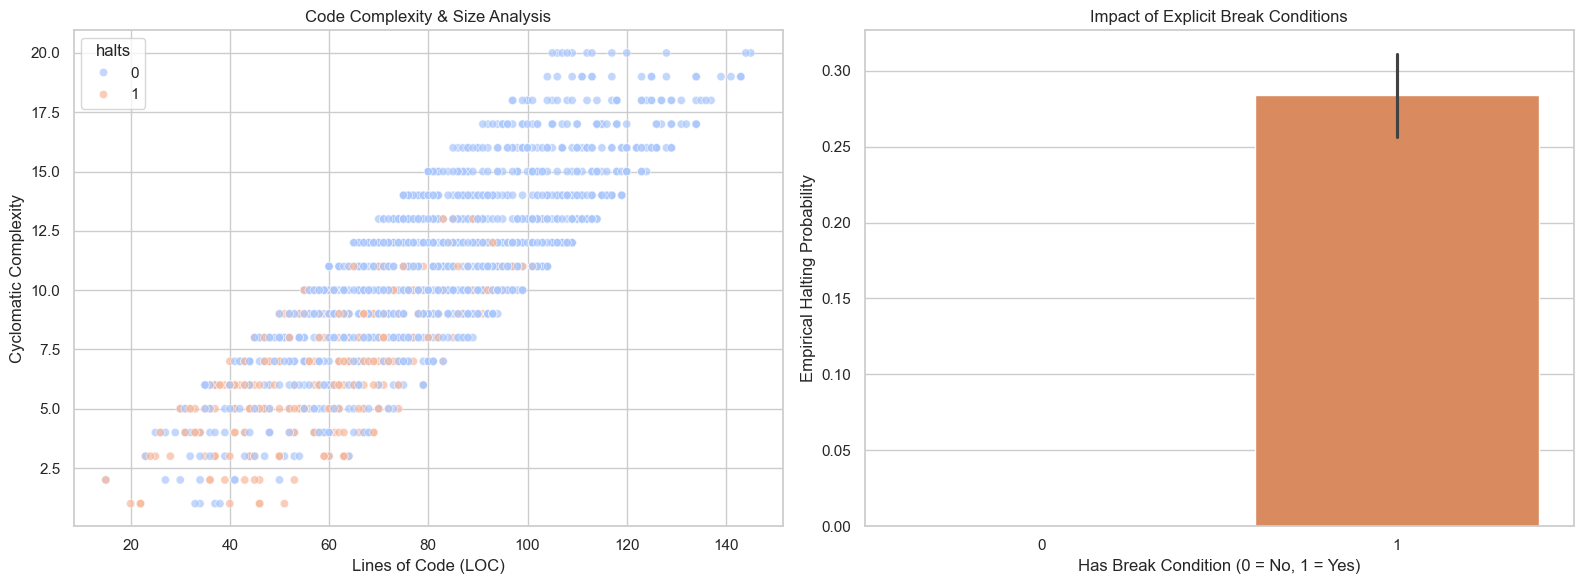

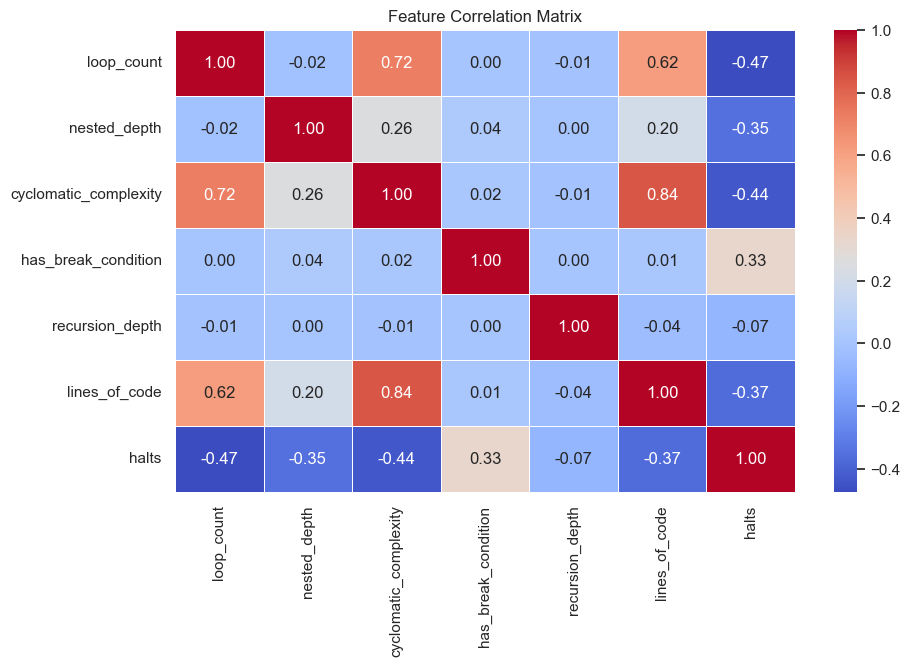

In [4]:
# Create a multi-plot figure to analyze feature behavior
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Cyclomatic Complexity vs Lines of Code categorized by execution outcome
sns.scatterplot(
    data=df, 
    x='lines_of_code', 
    y='cyclomatic_complexity', 
    hue='halts', 
    palette='coolwarm', 
    alpha=0.7, 
    ax=axes[0]
)
axes[0].set_title('Code Complexity & Size Analysis')
axes[0].set_xlabel('Lines of Code (LOC)')
axes[0].set_ylabel('Cyclomatic Complexity')

# Plot 2: Visualizing how explicit break conditions prevent infinite loops
sns.barplot(
    data=df, 
    x='has_break_condition', 
    y='halts', 
    palette='muted', 
    ax=axes[1]
)
axes[1].set_title('Impact of Explicit Break Conditions')
axes[1].set_xlabel('Has Break Condition (0 = No, 1 = Yes)')
axes[1].set_ylabel('Empirical Halting Probability')

plt.tight_layout()
plt.show()

# Plot 3: Feature Correlation Heatmap to inspect multicollinearity
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Feature Correlation Matrix')
plt.show()


## Model Training & Comparison

To approximate the Halting Problem, we evaluate two distinct machine learning approaches:
1. **Logistic Regression:** A linear model that estimates probabilities using the logistic sigmoid function. It serves as a baseline to check if the data is linearly separable.
2. **Random Forest Classifier:** An ensemble tree-based algorithm capable of capturing complex, non-linear feature interactions (such as nesting depth combined with missing break conditions).

We split the dataset into 80% for training and 20% for final validation, applying stratification to preserve class balance.


In [5]:
from sklearn.linear_model import LogisticRegression

# Separate explanatory features from the target label
X = df.drop(columns=['halts'])
y = df['halts']

# Perform stratified train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Define pipelines to automate scaling and prevention of data leakage
lr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', LogisticRegression(random_state=42))
])

rf_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42, max_depth=6))
])

# Train both architectures
lr_pipeline.fit(X_train, y_train)
rf_pipeline.fit(X_train, y_train)

# Generate predictions for evaluation
y_pred_lr = lr_pipeline.predict(X_test)
y_pred_rf = rf_pipeline.predict(X_test)

print("Models successfully trained and ready for performance comparison.")


Models successfully trained and ready for performance comparison.


In [6]:
print("================ LOGISTIC REGRESSION PERFORMANCE ================")
print(classification_report(y_test, y_pred_lr, target_names=['Infinite Loop (0)', 'Halts (1)']))

print("\n================== RANDOM FOREST PERFORMANCE ==================")
print(classification_report(y_test, y_pred_rf, target_names=['Infinite Loop (0)', 'Halts (1)']))


================ LOGISTIC REGRESSION PERFORMANCE ================
                   precision    recall  f1-score   support

Infinite Loop (0)       1.00      1.00      1.00       241
        Halts (1)       0.98      1.00      0.99        59

         accuracy                           1.00       300
        macro avg       0.99      1.00      0.99       300
     weighted avg       1.00      1.00      1.00       300


================== RANDOM FOREST PERFORMANCE ==================
                   precision    recall  f1-score   support

Infinite Loop (0)       1.00      0.99      0.99       241
        Halts (1)       0.95      0.98      0.97        59

         accuracy                           0.99       300
        macro avg       0.97      0.99      0.98       300
     weighted avg       0.99      0.99      0.99       300



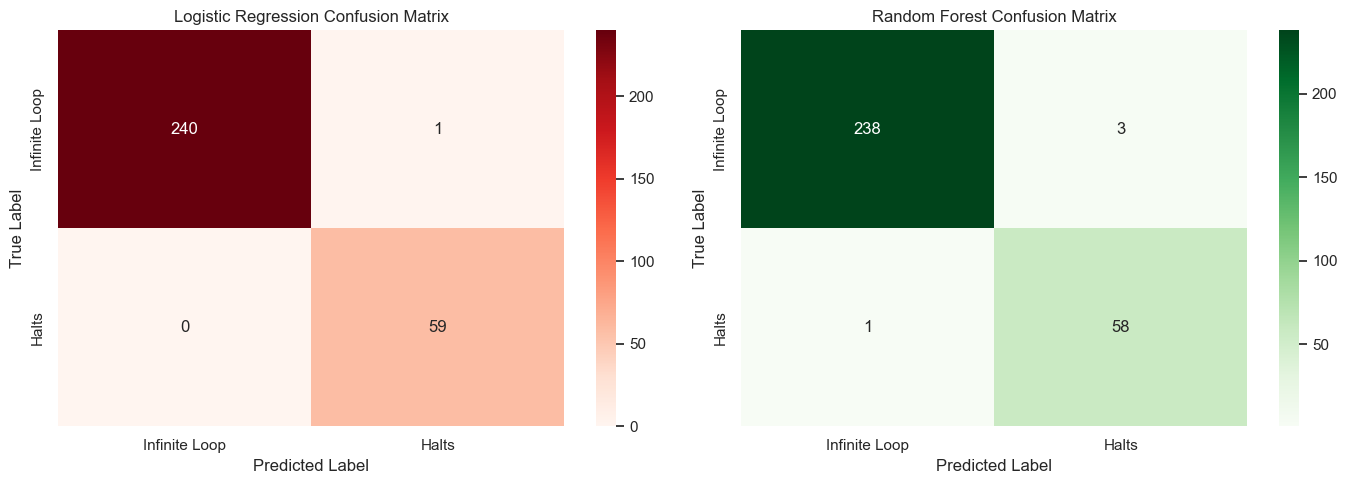

In [8]:
# Compute confusion matrices
cm_lr = confusion_matrix(y_test, y_pred_lr)
cm_rf = confusion_matrix(y_test, y_pred_rf)

# Create side-by-side subplots (1 row, 2 columns)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot Logistic Regression Confusion Matrix on the first subplot (index 0)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Reds', ax=axes[0],
            xticklabels=['Infinite Loop', 'Halts'], yticklabels=['Infinite Loop', 'Halts'])
axes[0].set_title('Logistic Regression Confusion Matrix')
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')

# Plot Random Forest Confusion Matrix on the second subplot (index 1)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=['Infinite Loop', 'Halts'], yticklabels=['Infinite Loop', 'Halts'])
axes[1].set_title('Random Forest Confusion Matrix')
axes[1].set_xlabel('Predicted Label')
axes[1].set_ylabel('True Label')

plt.tight_layout()
plt.show()


## Harder Synthetic Dataset: Mathematical Justification

The initial results yielded near-perfect validation scores ($1.00$ accuracy), indicating that the classes were linearly separable. In computational reality, estimating the Halting Problem is highly complex and non-linear. A static analyzer cannot determine termination based on single features independently; instead, it must capture non-linear feature interactions (co-dependencies).

To simulate a complex decision boundary, we reformulate the underlying latent score function $S(x)$ using polynomial interactions, trigonometric modulations (representing cyclic behavior changes), and stochastic noise:

$$S(x) = \beta_1 \cdot (\text{loop\_count} \times \text{nested\_depth}) + \beta_2 \cdot \left(\frac{\text{cyclomatic\_complexity}}{\text{has\_break\_condition} + 0.1}\right) + \beta_3 \cdot \sin(\text{recursion\_depth}) \cdot \text{lines\_of\_code} + \epsilon$$

Where:
* The first term represents a multi-variable interaction (deep nesting of multiple loops).
* The second term acts as a critical ratio where missing break conditions amplify complexity exponentially.
* The third term injects cyclic pattern shifts via the sine wave.
* $\epsilon \sim \mathcal{N}(0, \sigma^2)$ represents Gaussian noise, simulating the inherent uncertainty and fundamental undecidability of static code analysis.

We map this complex score back to probabilities via the standard Logistic Sigmoid:
$$P(Y = 1 \mid x) = \frac{1}{1 + e^{-S(x)}}$$


In [9]:
# Generate a complex, non-linear, and noisy dataset
np.random.seed(42)
num_samples = 2000  # Increased sample size for better learning overhead

# Generate base distributions
loop_count = np.random.randint(0, 6, num_samples)
nested_depth = np.random.randint(0, 5, num_samples)
has_break_condition = np.random.choice([0, 1], size=num_samples, p=[0.4, 0.6])
recursion_depth = np.random.randint(0, 25, num_samples)

# Derived architectural features
cyclomatic_complexity = (loop_count * 3) + (nested_depth * 2) + np.random.randint(1, 15, num_samples)
lines_of_code = (cyclomatic_complexity * 6) + (recursion_depth * 2) + np.random.randint(10, 100, num_samples)

# Assemble features into a temporary DataFrame
df_hard = pd.DataFrame({
    'loop_count': loop_count,
    'nested_depth': nested_depth,
    'cyclomatic_complexity': cyclomatic_complexity,
    'has_break_condition': has_break_condition,
    'recursion_depth': recursion_depth,
    'lines_of_code': lines_of_code
})

# Construct the non-linear mathematical score formula
interaction_term = df_hard['loop_count'] * df_hard['nested_depth'] * 1.5
critical_ratio_term = df_hard['cyclomatic_complexity'] / (df_hard['has_break_condition'] + 0.2) * 0.4
cyclic_recursion_term = np.sin(df_hard['recursion_depth']) * (df_hard['lines_of_code'] / 10.0)

# Add standard Gaussian noise to obscure the decision boundary
gaussian_noise = np.random.normal(0, 2.5, num_samples)

# Final raw equation score
raw_score = interaction_term + critical_ratio_term + cyclic_recursion_term + gaussian_noise

# Standard scaling applied inside sigmoid function to prevent overflow and balance classes
standardized_score = (raw_score - raw_score.mean()) / raw_score.std()
probability_hard = 1 / (1 + np.exp(-standardized_score))

# Map to binary class outcomes (1 = Halts, 0 = Infinite Loop)
df_hard['halts'] = (probability_hard > 0.5).astype(int)

print(f"Hard dataset generation complete. Configuration matrix size: {df_hard.shape}")
print("\nNew Balanced Class Distribution:")
print(df_hard['halts'].value_counts(normalize=True))


Hard dataset generation complete. Configuration matrix size: (2000, 7)

New Balanced Class Distribution:
halts
0    0.5675
1    0.4325
Name: proportion, dtype: float64


In [10]:
# Extract new dataset configurations
X_hard = df_hard.drop(columns=['halts'])
y_hard = df_hard['halts']

# Split using the new dataset configurations
X_train_h, X_test_h, y_train_h, y_test_h = train_test_split(
    X_hard, y_hard, test_size=0.2, random_state=42, stratify=y_hard
)

# Re-train pipelines using the same architectures
lr_pipeline.fit(X_train_h, y_train_h)
rf_pipeline.fit(X_train_h, y_train_h)

# Execute predictions on the unseen test matrix
y_pred_lr_h = lr_pipeline.predict(X_test_h)
y_pred_rf_h = rf_pipeline.predict(X_test_h)

print("============ LOGISTIC REGRESSION (HARD DATASET) ============")
print(classification_report(y_test_h, y_pred_lr_h, target_names=['Infinite Loop (0)', 'Halts (1)']))

print("\n============== RANDOM FOREST (HARD DATASET) ==============")
print(classification_report(y_test_h, y_pred_rf_h, target_names=['Infinite Loop (0)', 'Halts (1)']))


============ LOGISTIC REGRESSION (HARD DATASET) ============
                   precision    recall  f1-score   support

Infinite Loop (0)       0.81      0.84      0.82       227
        Halts (1)       0.78      0.73      0.76       173

         accuracy                           0.80       400
        macro avg       0.79      0.79      0.79       400
     weighted avg       0.79      0.80      0.79       400


============== RANDOM FOREST (HARD DATASET) ==============
                   precision    recall  f1-score   support

Infinite Loop (0)       0.84      0.89      0.87       227
        Halts (1)       0.85      0.78      0.81       173

         accuracy                           0.84       400
        macro avg       0.85      0.84      0.84       400
     weighted avg       0.85      0.84      0.84       400

